In [1]:
from sklearn.metrics import precision_recall_curve, auc

In [2]:
# =========================================
# 06B_grouped_extreme_classification.ipynb
# DOI-grouped extreme-class stability classification
# =========================================
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)

WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

X_FILE = os.path.join(WORK_DIR, "interim", "X_features.parquet")
Y_FILE = os.path.join(WORK_DIR, "interim", "y_target.parquet")
GROUP_FILE = os.path.join(WORK_DIR, "interim", "groups.parquet")
ROWID_FILE = os.path.join(WORK_DIR, "interim", "row_ids.parquet")

REPORT_DIR = os.path.join(WORK_DIR, "reports")
META_DIR = os.path.join(WORK_DIR, "metadata")
ARTIFACT_DIR = os.path.join(WORK_DIR, "artifacts", "06B_extreme_classification")

for p in [REPORT_DIR, META_DIR, ARTIFACT_DIR]:
    os.makedirs(p, exist_ok=True)

In [3]:
X = pd.read_parquet(X_FILE)
y = pd.read_parquet(Y_FILE)["T80_log1p"].copy()
groups = pd.read_parquet(GROUP_FILE)["Ref_DOI_number"].copy()
row_ids = pd.read_parquet(ROWID_FILE)["raw_row_id"].copy()

assert len(X) == len(y) == len(groups) == len(row_ids)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("unique DOI:", groups.nunique())

X shape: (1835, 77)
y shape: (1835,)
unique DOI: 964


In [4]:
quantile_settings = [
    ("30_70", 0.30, 0.70),
    ("25_75", 0.25, 0.75),
]

all_gss_scores = []
all_gss_summaries = []
all_gkf_scores = []
all_gkf_summaries = []

prepared_datasets = {}

for setting_name, LOW_Q, HIGH_Q in quantile_settings:
    q_low = y.quantile(LOW_Q)
    q_high = y.quantile(HIGH_Q)

    keep_mask = (y <= q_low) | (y >= q_high)

    X_cls = X.loc[keep_mask].copy()
    y_cls = y.loc[keep_mask].copy()
    groups_cls = groups.loc[keep_mask].copy()
    row_ids_cls = row_ids.loc[keep_mask].copy()

    # 0 = low stability, 1 = high stability
    y_bin = (y_cls >= q_high).astype(int)

    prepared_datasets[setting_name] = {
        "LOW_Q": LOW_Q,
        "HIGH_Q": HIGH_Q,
        "q_low": q_low,
        "q_high": q_high,
        "X_cls": X_cls,
        "y_cls": y_cls,
        "groups_cls": groups_cls,
        "row_ids_cls": row_ids_cls,
        "y_bin": y_bin,
    }

    print("\n===================================")
    print("Setting:", setting_name)
    print("q_low:", q_low)
    print("q_high:", q_high)
    print("Classification rows kept:", len(X_cls))
    print("Low class count:", int((y_bin == 0).sum()))
    print("High class count:", int((y_bin == 1).sum()))
    print("Unique DOI kept:", groups_cls.nunique())


Setting: 30_70
q_low: 3.9318256327243257
q_high: 5.8888779583328805
Classification rows kept: 1120
Low class count: 557
High class count: 563
Unique DOI kept: 683

Setting: 25_75
q_low: 3.6109179126442243
q_high: 6.148322171857281
Classification rows kept: 921
Low class count: 462
High class count: 459
Unique DOI kept: 564


In [5]:
def evaluate_binary(y_true, y_prob, y_pred):
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "n_test": len(y_true),
    }

def summarize_scores(df_scores, split_name, model_name):
    out = {"split": split_name, "model": model_name, "n_runs": len(df_scores)}
    for m in ["roc_auc", "pr_auc", "balanced_acc", "f1", "n_test"]:
        out[f"{m}_mean"] = df_scores[m].mean()
        out[f"{m}_std"] = df_scores[m].std(ddof=1) if len(df_scores) > 1 else 0.0
    return out

In [6]:
models = {
    "logistic": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=SEED
        ))
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED
        ))
    ]),
    "hist_gb": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=6,
            max_iter=400,
            min_samples_leaf=10,
            random_state=SEED
        ))
    ]),
}

print("Models:", list(models.keys()))

Models: ['logistic', 'random_forest', 'hist_gb']


In [7]:
def run_group_shuffle_classification(X, y_bin, groups, models, n_repeats=30, test_size=0.2, seed=42):
    all_scores = []
    fitted_examples = {}

    splitter = GroupShuffleSplit(
        n_splits=n_repeats,
        test_size=test_size,
        random_state=seed
    )

    for rep, (train_idx, test_idx) in enumerate(splitter.split(X, y_bin, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y_bin.iloc[train_idx]
        y_test = y_bin.iloc[test_idx]
        g_test = groups.iloc[test_idx]

        for model_name, model in models.items():
            t0 = time.time()
            model.fit(X_train, y_train)

            y_prob = model.predict_proba(X_test)[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)

            metrics = evaluate_binary(y_test, y_prob, y_pred)
            metrics["split"] = "group_shuffle_split"
            metrics["model"] = model_name
            metrics["repeat"] = rep
            metrics["fit_seconds"] = time.time() - t0
            metrics["n_test_groups"] = g_test.nunique()
            all_scores.append(metrics)

            fitted_examples[model_name] = {
                "y_true": np.array(y_test),
                "y_prob": np.array(y_prob),
                "y_pred": np.array(y_pred)
            }

    return pd.DataFrame(all_scores), fitted_examples

gss_example_store = {}

for setting_name, ds in prepared_datasets.items():
    print("\n==============================")
    print("GroupShuffleSplit:", setting_name)
    print("==============================")

    gss_scores, gss_examples = run_group_shuffle_classification(
        X=ds["X_cls"],
        y_bin=ds["y_bin"],
        groups=ds["groups_cls"],
        models=models,
        n_repeats=30,
        test_size=0.2,
        seed=SEED
    )

    gss_scores["setting"] = setting_name
    all_gss_scores.append(gss_scores)

    gss_summary_rows = []
    for model_name in gss_scores["model"].unique():
        dfm = gss_scores[gss_scores["model"] == model_name].copy()
        row = summarize_scores(dfm, "group_shuffle_split", model_name)
        row["setting"] = setting_name
        row["rows_after_filtering"] = int(len(ds["X_cls"]))
        row["n_unique_doi"] = int(ds["groups_cls"].nunique())
        gss_summary_rows.append(row)

    gss_summary = pd.DataFrame(gss_summary_rows).sort_values("roc_auc_mean", ascending=False)
    all_gss_summaries.append(gss_summary)

    gss_example_store[setting_name] = gss_examples

    print(gss_summary)


GroupShuffleSplit: 30_70
                 split          model  n_runs  roc_auc_mean  roc_auc_std  \
1  group_shuffle_split  random_forest      30      0.747551     0.038018   
0  group_shuffle_split       logistic      30      0.724075     0.042451   
2  group_shuffle_split        hist_gb      30      0.690855     0.042032   

   pr_auc_mean  pr_auc_std  balanced_acc_mean  balanced_acc_std   f1_mean  \
1     0.721615    0.049244           0.689193          0.033735  0.697359   
0     0.686852    0.058081           0.681141          0.032338  0.692410   
2     0.665896    0.062988           0.653422          0.034706  0.667969   

     f1_std  n_test_mean  n_test_std setting  rows_after_filtering  \
1  0.033224   223.933333   13.122587   30_70                  1120   
0  0.030404   223.933333   13.122587   30_70                  1120   
2  0.036803   223.933333   13.122587   30_70                  1120   

   n_unique_doi  
1           683  
0           683  
2           683  

GroupS

In [8]:
gss_scores_all = pd.concat(all_gss_scores, axis=0, ignore_index=True)
gss_summary_all = pd.concat(all_gss_summaries, axis=0, ignore_index=True)

print("Combined GroupShuffleSplit summary:")
print(
    gss_summary_all.sort_values(
        ["setting", "roc_auc_mean"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

Combined GroupShuffleSplit summary:
                 split          model  n_runs  roc_auc_mean  roc_auc_std  \
0  group_shuffle_split  random_forest      30      0.752105     0.039815   
1  group_shuffle_split       logistic      30      0.741168     0.044489   
2  group_shuffle_split        hist_gb      30      0.717180     0.047211   
3  group_shuffle_split  random_forest      30      0.747551     0.038018   
4  group_shuffle_split       logistic      30      0.724075     0.042451   
5  group_shuffle_split        hist_gb      30      0.690855     0.042032   

   pr_auc_mean  pr_auc_std  balanced_acc_mean  balanced_acc_std   f1_mean  \
0     0.731463    0.054386           0.687382          0.041519  0.692039   
1     0.701191    0.078940           0.689904          0.042018  0.702225   
2     0.683748    0.072488           0.668318          0.041619  0.680301   
3     0.721615    0.049244           0.689193          0.033735  0.697359   
4     0.686852    0.058081           0.681141 

In [9]:
def run_group_kfold_classification(X, y_bin, groups, models, n_splits=5):
    all_scores = []
    fitted_examples = {}

    splitter = GroupKFold(n_splits=n_splits)

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y_bin, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y_bin.iloc[train_idx]
        y_test = y_bin.iloc[test_idx]
        g_test = groups.iloc[test_idx]

        for model_name, model in models.items():
            t0 = time.time()
            model.fit(X_train, y_train)

            y_prob = model.predict_proba(X_test)[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)

            metrics = evaluate_binary(y_test, y_prob, y_pred)
            metrics["split"] = "group_kfold"
            metrics["model"] = model_name
            metrics["fold"] = fold
            metrics["fit_seconds"] = time.time() - t0
            metrics["n_test_groups"] = g_test.nunique()

            all_scores.append(metrics)

            fitted_examples[model_name] = {
                "y_true": np.array(y_test),
                "y_prob": np.array(y_prob),
                "y_pred": np.array(y_pred)
            }

    return pd.DataFrame(all_scores), fitted_examples

In [10]:
gkf_example_store = {}

for setting_name, ds in prepared_datasets.items():
    print("\n==============================")
    print("GroupKFold:", setting_name)
    print("==============================")

    gkf_scores, gkf_examples = run_group_kfold_classification(
        X=ds["X_cls"],
        y_bin=ds["y_bin"],
        groups=ds["groups_cls"],
        models=models,
        n_splits=5
    )

    gkf_scores["setting"] = setting_name
    all_gkf_scores.append(gkf_scores)

    gkf_summary_rows = []
    for model_name in gkf_scores["model"].unique():
        dfm = gkf_scores[gkf_scores["model"] == model_name].copy()
        row = summarize_scores(dfm, "group_kfold", model_name)
        row["setting"] = setting_name
        row["rows_after_filtering"] = int(len(ds["X_cls"]))
        row["n_unique_doi"] = int(ds["groups_cls"].nunique())
        gkf_summary_rows.append(row)

    gkf_summary = pd.DataFrame(gkf_summary_rows).sort_values("roc_auc_mean", ascending=False)
    all_gkf_summaries.append(gkf_summary)

    gkf_example_store[setting_name] = gkf_examples

    print(gkf_summary)


GroupKFold: 30_70
         split          model  n_runs  roc_auc_mean  roc_auc_std  pr_auc_mean  \
1  group_kfold  random_forest       5      0.747501     0.052379     0.717537   
0  group_kfold       logistic       5      0.722132     0.038055     0.689442   
2  group_kfold        hist_gb       5      0.695377     0.046490     0.674088   

   pr_auc_std  balanced_acc_mean  balanced_acc_std   f1_mean    f1_std  \
1    0.093156           0.687162          0.046924  0.702230  0.054933   
0    0.081584           0.664737          0.035097  0.681762  0.045223   
2    0.081532           0.643909          0.013624  0.667865  0.035854   

   n_test_mean  n_test_std setting  rows_after_filtering  n_unique_doi  
1        224.0         0.0   30_70                  1120           683  
0        224.0         0.0   30_70                  1120           683  
2        224.0         0.0   30_70                  1120           683  

GroupKFold: 25_75
         split          model  n_runs  roc_auc_m

In [11]:
gkf_scores_all = pd.concat(all_gkf_scores, axis=0, ignore_index=True)
gkf_summary_all = pd.concat(all_gkf_summaries, axis=0, ignore_index=True)

print("Combined GroupKFold summary:")
print(
    gkf_summary_all.sort_values(
        ["setting", "roc_auc_mean"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

Combined GroupKFold summary:
         split          model  n_runs  roc_auc_mean  roc_auc_std  pr_auc_mean  \
0  group_kfold  random_forest       5      0.763130     0.061767     0.750319   
1  group_kfold       logistic       5      0.740872     0.045237     0.704205   
2  group_kfold        hist_gb       5      0.728493     0.031487     0.688199   
3  group_kfold  random_forest       5      0.747501     0.052379     0.717537   
4  group_kfold       logistic       5      0.722132     0.038055     0.689442   
5  group_kfold        hist_gb       5      0.695377     0.046490     0.674088   

   pr_auc_std  balanced_acc_mean  balanced_acc_std   f1_mean    f1_std  \
0    0.039394           0.688413          0.058587  0.699743  0.033991   
1    0.033943           0.695278          0.053428  0.715562  0.029172   
2    0.051674           0.674729          0.033794  0.690086  0.018131   
3    0.093156           0.687162          0.046924  0.702230  0.054933   
4    0.081584           0.664737 

In [12]:
gss_scores_all.to_csv(
    os.path.join(REPORT_DIR, "06B_extreme_cls_group_shuffle_all_scores_quantile_compare.csv"),
    index=False
)
gss_summary_all.to_csv(
    os.path.join(REPORT_DIR, "06B_extreme_cls_group_shuffle_summary_quantile_compare.csv"),
    index=False
)

gkf_scores_all.to_csv(
    os.path.join(REPORT_DIR, "06B_extreme_cls_group_kfold_all_scores_quantile_compare.csv"),
    index=False
)
gkf_summary_all.to_csv(
    os.path.join(REPORT_DIR, "06B_extreme_cls_group_kfold_summary_quantile_compare.csv"),
    index=False
)

print("Saved quantile-comparison classification reports.")

Saved quantile-comparison classification reports.



Best extreme-class model for 30_70 : random_forest


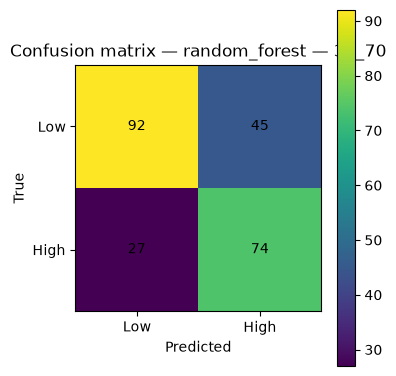

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06B_extreme_classification\06B_confusion_matrix_random_forest_30_70.png

Best extreme-class model for 25_75 : random_forest


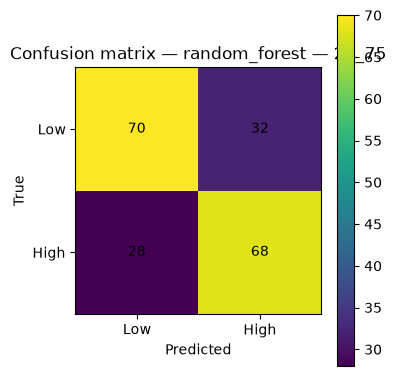

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06B_extreme_classification\06B_confusion_matrix_random_forest_25_75.png


In [13]:
for setting_name in prepared_datasets.keys():
    gss_summary_this = (
        gss_summary_all[gss_summary_all["setting"] == setting_name]
        .sort_values("roc_auc_mean", ascending=False)
        .reset_index(drop=True)
    )

    best_model_name = gss_summary_this.iloc[0]["model"]
    print("\nBest extreme-class model for", setting_name, ":", best_model_name)

    y_true = gss_example_store[setting_name][best_model_name]["y_true"]
    y_pred = gss_example_store[setting_name][best_model_name]["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion matrix — {best_model_name} — {setting_name}")
    plt.colorbar()
    plt.xticks([0, 1], ["Low", "High"])
    plt.yticks([0, 1], ["Low", "High"])
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    out = os.path.join(
        ARTIFACT_DIR,
        f"06B_confusion_matrix_{best_model_name}_{setting_name}.png"
    )
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

In [14]:
overall = pd.concat([gss_summary_all, gkf_summary_all], axis=0, ignore_index=True)
overall = overall.sort_values(
    ["setting", "split", "roc_auc_mean"],
    ascending=[True, True, False]
).reset_index(drop=True)

overall.to_csv(
    os.path.join(REPORT_DIR, "06B_extreme_cls_overall_summary_quantile_compare.csv"),
    index=False
)

print("Overall quantile comparison summary:")
overall

Overall quantile comparison summary:


,split,model,n_runs,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_acc_mean,balanced_acc_std,f1_mean,f1_std,n_test_mean,n_test_std,setting,rows_after_filtering,n_unique_doi
0,group_kfold,random_forest,5,0.763130,0.061767,0.750319,0.039394,0.688413,0.058587,0.699743,0.033991,184.200000,0.447214,25_75,921,564
1,group_kfold,logistic,5,0.740872,0.045237,0.704205,0.033943,0.695278,0.053428,0.715562,0.029172,184.200000,0.447214,25_75,921,564
2,group_kfold,hist_gb,5,0.728493,0.031487,0.688199,0.051674,0.674729,0.033794,0.690086,0.018131,184.200000,0.447214,25_75,921,564
3,group_shuffle_split,random_forest,30,0.752105,0.039815,0.731463,0.054386,0.687382,0.041519,0.692039,0.047156,185.500000,10.341580,25_75,921,564
4,group_shuffle_split,logistic,30,0.741168,0.044489,0.701191,0.078940,0.689904,0.042018,0.702225,0.046763,185.500000,10.341580,25_75,921,564
5,group_shuffle_split,hist_gb,30,0.717180,0.047211,0.683748,0.072488,0.668318,0.041619,0.680301,0.043349,185.500000,10.341580,25_75,921,564
6,group_kfold,random_forest,5,0.747501,0.052379,0.717537,0.093156,0.687162,0.046924,0.702230,0.054933,224.000000,0.000000,30_70,1120,683
7,group_kfold,logistic,5,0.722132,0.038055,0.689442,0.081584,0.664737,0.035097,0.681762,0.045223,224.000000,0.000000,30_70,1120,683
8,group_kfold,hist_gb,5,0.695377,0.046490,0.674088,0.081532,0.643909,0.013624,0.667865,0.035854,224.000000,0.000000,30_70,1120,683
9,group_shuffle_split,random_forest,30,0.747551,0.038018,0.721615,0.049244,0.689193,0.033735,0.697359,0.033224,223.933333,13.122587,30_70,1120,683


In [15]:
best_rows = (
    overall.sort_values(["setting", "roc_auc_mean"], ascending=[True, False])
    .groupby("setting", as_index=False)
    .first()
)

card = {
    "notebook": "06B_grouped_extreme_classification.ipynb",
    "inputs": {
        "X": X_FILE,
        "y": Y_FILE,
        "groups": GROUP_FILE,
        "row_ids": ROWID_FILE
    },
    "label_designs": {
        setting_name: {
            "low_quantile": prepared_datasets[setting_name]["LOW_Q"],
            "high_quantile": prepared_datasets[setting_name]["HIGH_Q"],
            "middle_region_removed": True,
            "rows_after_filtering": int(len(prepared_datasets[setting_name]["X_cls"])),
            "n_unique_doi": int(prepared_datasets[setting_name]["groups_cls"].nunique()),
            "n_low_class": int((prepared_datasets[setting_name]["y_bin"] == 0).sum()),
            "n_high_class": int((prepared_datasets[setting_name]["y_bin"] == 1).sum()),
        }
        for setting_name in prepared_datasets.keys()
    },
    "best_model_per_setting": best_rows[["setting", "split", "model", "roc_auc_mean"]].to_dict(orient="records")
}

card_path = os.path.join(META_DIR, "06B_extreme_classification_card_quantile_compare.json")
with open(card_path, "w", encoding="utf-8") as f:
    json.dump(card, f, indent=4)

print("Saved:", card_path)
print("DONE.")

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\metadata\06B_extreme_classification_card_quantile_compare.json
DONE.


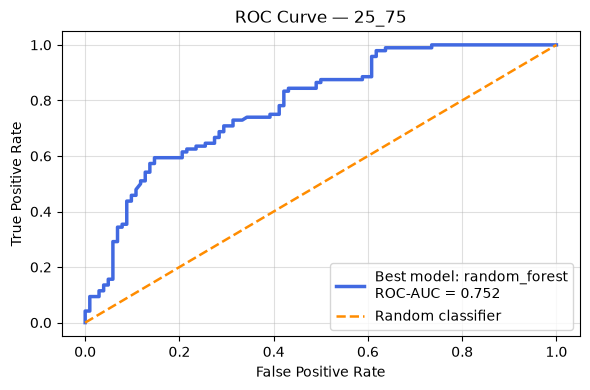

In [16]:
for setting_name in prepared_datasets.keys():

  best_row = (
        gss_summary_all[gss_summary_all["setting"] == setting_name]
        .sort_values("roc_auc_mean", ascending=False)
        .iloc[0]
    )

best_model_name = best_row["model"]
roc_auc_mean = best_row["roc_auc_mean"]   

y_true = gss_example_store[setting_name][best_model_name]["y_true"]
y_prob = gss_example_store[setting_name][best_model_name]["y_prob"]
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr,color="royalblue",linewidth=2.5, label=f"Best model: {best_model_name}\nROC-AUC = {roc_auc_mean:.3f}")
plt.plot([0, 1], [0, 1], color="darkorange",linestyle="--", linewidth=1.8,label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {setting_name}")

plt.grid(alpha=0.4)
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, f"roc_curve_{setting_name}_{best_model_name}.png"),dpi=600)
plt.show()

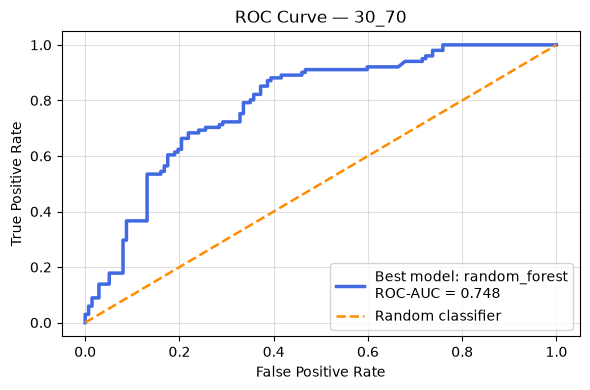

In [17]:
setting_name = "30_70"

best_row = (
    gss_summary_all[gss_summary_all["setting"] == setting_name]
    .sort_values("roc_auc_mean", ascending=False)
    .iloc[0]
)

best_model_name = best_row["model"]
roc_auc_mean = best_row["roc_auc_mean"]

y_true = gss_example_store[setting_name][best_model_name]["y_true"]
y_prob = gss_example_store[setting_name][best_model_name]["y_prob"]

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr,color="royalblue", linewidth=2.5, label=f"Best model: {best_model_name}\nROC-AUC = {roc_auc_mean:.3f}")

plt.plot([0, 1], [0, 1], color="darkorange",linestyle="--",linewidth=1.8, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — 30_70")

plt.grid(alpha=0.4)
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, f"roc_curve_{setting_name}_{best_model_name}.png"),dpi=600)
plt.show()

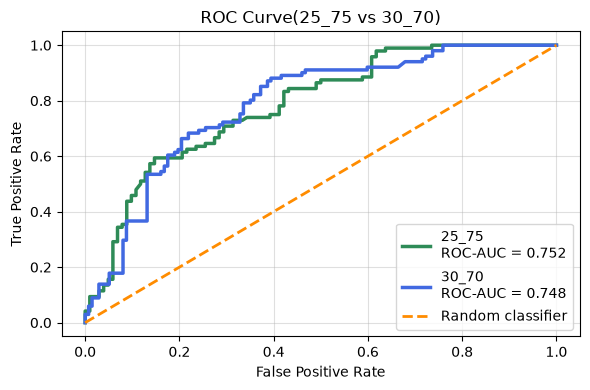

In [18]:
plt.figure(figsize=(6,4))

setting_1 = "25_75"
best_row_1 = (gss_summary_all[gss_summary_all["setting"] == setting_1].sort_values("roc_auc_mean", ascending=False).iloc[0])

model_1 = best_row_1["model"]
auc_1 = best_row_1["roc_auc_mean"]

y_true_1 = gss_example_store[setting_1][model_1]["y_true"]
y_prob_1 = gss_example_store[setting_1][model_1]["y_prob"]

fpr_1, tpr_1, _ = roc_curve(y_true_1, y_prob_1)

plt.plot( fpr_1, tpr_1,color="seagreen",linewidth=2.5,label=f"25_75\nROC-AUC = {auc_1:.3f}")

setting_2 = "30_70"

best_row_2 = (gss_summary_all[gss_summary_all["setting"] == setting_2].sort_values("roc_auc_mean", ascending=False).iloc[0])

model_2 = best_row_2["model"]
auc_2 = best_row_2["roc_auc_mean"]

y_true_2 = gss_example_store[setting_2][model_2]["y_true"]
y_prob_2 = gss_example_store[setting_2][model_2]["y_prob"]

fpr_2, tpr_2, _ = roc_curve(y_true_2, y_prob_2)

plt.plot(fpr_2, tpr_2,color="royalblue",linewidth=2.5,label=f"30_70 \nROC-AUC = {auc_2:.3f}")

plt.plot([0, 1], [0, 1],color="darkorange",linestyle="--", linewidth=2,label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve(25_75 vs 30_70)")

plt.grid(alpha=0.4)
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "roc_comparison_25_75_vs_30_70.png"),dpi=600, bbox_inches="tight")
plt.show()

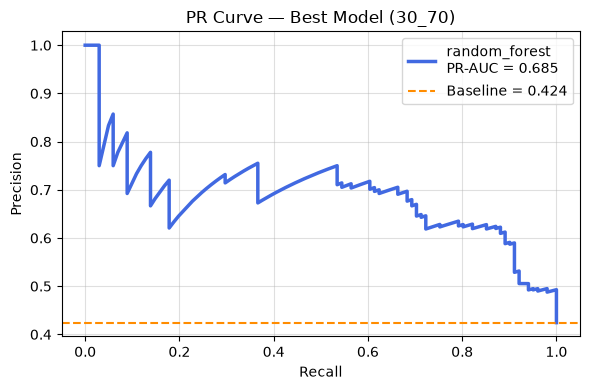

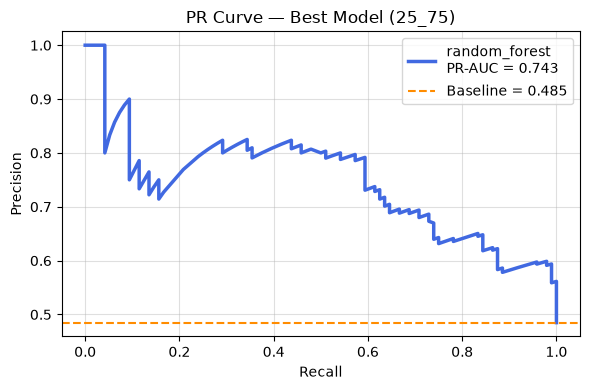

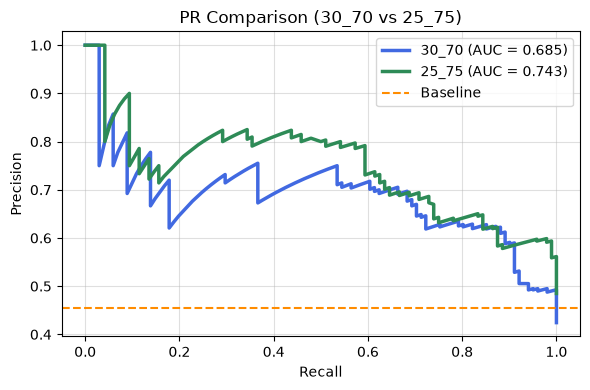

In [19]:
# =========================
# Function to get best PR data
# =========================
def get_best_pr(setting_name):
    best_row = (
        gss_summary_all[gss_summary_all["setting"] == setting_name]
        .sort_values("roc_auc_mean", ascending=False)
        .iloc[0]
    )

    model = best_row["model"]

    y_true = gss_example_store[setting_name][model]["y_true"]
    y_prob = gss_example_store[setting_name][model]["y_prob"]

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    baseline = np.mean(y_true)

    return model, pr_auc, baseline, precision, recall


# =========================
# 1) Best 30_70
# =========================
model_30, auc_30, base_30, prec_30, rec_30 = get_best_pr("30_70")

plt.figure(figsize=(6,4))

plt.plot(rec_30, prec_30, color="royalblue", linewidth=2.5,
         label=f"{model_30}\nPR-AUC = {auc_30:.3f}")

plt.axhline(base_30, linestyle="--", color="darkorange",
            label=f"Baseline = {base_30:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve — Best Model (30_70)")

plt.grid(alpha=0.4)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "pr_30_70.png"), dpi=600)
plt.show()


# =========================
# 2) Best 25_75
# =========================
model_25, auc_25, base_25, prec_25, rec_25 = get_best_pr("25_75")

plt.figure(figsize=(6,4))

plt.plot(rec_25, prec_25, color="royalblue", linewidth=2.5,
         label=f"{model_25}\nPR-AUC = {auc_25:.3f}")

plt.axhline(base_25, linestyle="--", color="darkorange",
            label=f"Baseline = {base_25:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve — Best Model (25_75)")

plt.grid(alpha=0.4)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "pr_25_75.png"), dpi=600)
plt.show()


# =========================
# 3) Comparison
# =========================
plt.figure(figsize=(6,4))

plt.plot(rec_30, prec_30, color="royalblue", linewidth=2.5,
         label=f"30_70 (AUC = {auc_30:.3f})")

plt.plot(rec_25, prec_25, color="seagreen", linewidth=2.5,
         label=f"25_75 (AUC = {auc_25:.3f})")

plt.axhline((base_30 + base_25)/2, linestyle="--", color="darkorange",
            label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Comparison (30_70 vs 25_75)")

plt.grid(alpha=0.4)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "pr_comparison.png"), dpi=600)
plt.show()

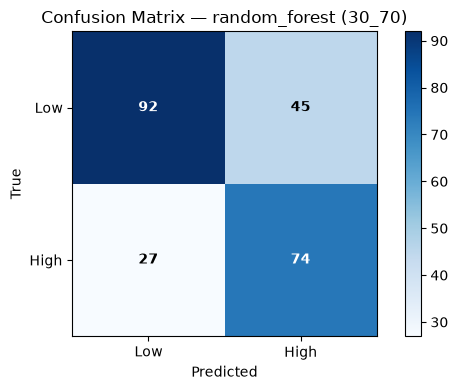

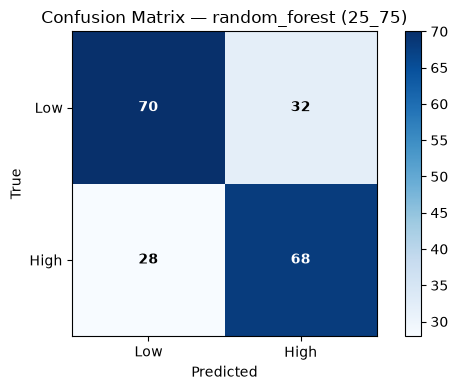

In [20]:
for setting_name in prepared_datasets.keys():
    best_row = (
        gss_summary_all[gss_summary_all["setting"] == setting_name]
        .sort_values("roc_auc_mean", ascending=False)
        .iloc[0]
    )

    best_model_name = best_row["model"]

    y_true = gss_example_store[setting_name][best_model_name]["y_true"]
    y_pred = gss_example_store[setting_name][best_model_name]["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))

    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Confusion Matrix — {best_model_name} ({setting_name})")
    plt.colorbar()

    class_labels = ["Low", "High"]
    plt.xticks([0, 1], class_labels)
    plt.yticks([0, 1], class_labels)

    plt.xlabel("Predicted")
    plt.ylabel("True")


    threshold = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, f"{cm[i, j]}",
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontweight="bold"
            )

    plt.tight_layout()

    plt.savefig(os.path.join(ARTIFACT_DIR, f"confusion_matrix_{setting_name}_{best_model_name}.png"), dpi=600 )

    plt.show()

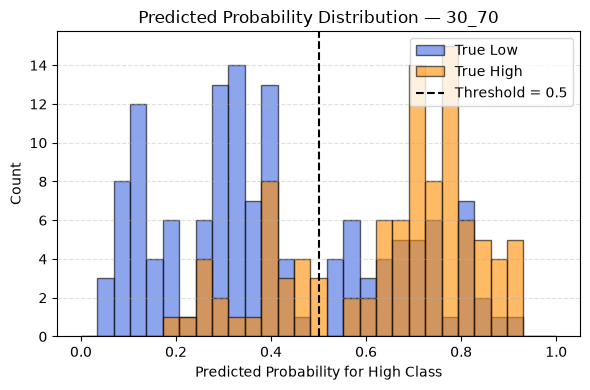

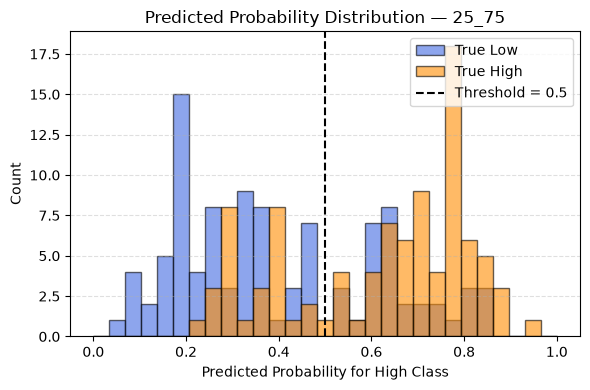

In [21]:
for setting_name in prepared_datasets.keys():
    best_row = (
        gss_summary_all[gss_summary_all["setting"] == setting_name]
        .sort_values("roc_auc_mean", ascending=False)
        .iloc[0]
    )
    
    best_model_name = best_row["model"]

    y_true = gss_example_store[setting_name][best_model_name]["y_true"]
    y_prob = gss_example_store[setting_name][best_model_name]["y_prob"]

    plt.figure(figsize=(6,4))

 
    bins = np.linspace(0, 1, 30)

    plt.hist(
        y_prob[y_true == 0],
        bins=bins,
        alpha=0.6,
        color="royalblue",
        edgecolor="black",
        label="True Low"
    )

    plt.hist(
        y_prob[y_true == 1],
        bins=bins,
        alpha=0.6,
        color="darkorange",
        edgecolor="black",
        label="True High"
    )

  
    plt.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold = 0.5")

    plt.xlabel("Predicted Probability for High Class")
    plt.ylabel("Count")
    plt.title(f"Predicted Probability Distribution — {setting_name}")

    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend(loc="best")
    plt.tight_layout()

    plt.savefig( os.path.join(ARTIFACT_DIR, f"probability_distribution_{setting_name}_{best_model_name}.png"),dpi=600)
    plt.show()